# Homework 12 — Stakeholder Reporting & Delivery Design
This reproducible notebook creates an investment-committee report from a self-contained 12-month scenario dataset and exports every final visual to `reports/images/`.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib

## Executive Summary
- **Retain the baseline as the planning case:** expected return is 12.0% at 18.0% volatility.
- **Do not select assumptions only for the highest return:** the outlier-rule case raises expected return by 1.5 percentage points but also raises volatility by 1.0 point.
- **Use a decision range, not a single forecast:** plausible assumption changes move expected return from 11.0% to 13.5%.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(101)

## Load Your Data
You can load your real results or use a generated synthetic dataset as fallback.

In [3]:
data_path = Path('data/processed/final_results.csv')

if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Reproducible 12-month scenario dataset.
    scenario_specs = {
        'Baseline': {'expected_return': 0.120, 'volatility': 0.180, 'assumption': 'Median imputation'},
        'Mean imputation': {'expected_return': 0.110, 'volatility': 0.185, 'assumption': 'Mean imputation'},
        '3σ outlier rule': {'expected_return': 0.135, 'volatility': 0.190, 'assumption': 'Keep observations within 3σ'},
    }
    dates = pd.date_range('2025-01-31', periods=12, freq='ME')
    common_pattern = np.array([0.6, -0.4, 1.2, 0.3, -0.7, 0.8, 0.2, -0.5, 1.0, 0.1, -0.3, 0.7])
    rows = []
    for scenario, spec in scenario_specs.items():
        monthly_base = (1 + spec['expected_return']) ** (1/12) - 1
        monthly_returns = monthly_base + common_pattern * spec['volatility'] / np.sqrt(12) * 0.20
        wealth = np.cumprod(1 + monthly_returns)
        for date, monthly_return, growth in zip(dates, monthly_returns, wealth):
            rows.append({**spec, 'scenario': scenario, 'Date': date,
                         'monthly_return': monthly_return, 'growth_of_one': growth})
    df = pd.DataFrame(rows)
    data_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(data_path, index=False)
df['Date'] = pd.to_datetime(df['Date'])
df['sharpe'] = (df['expected_return'] - 0.02) / df['volatility']
df.head()

,expected_return,volatility,assumption,scenario,Date,monthly_return,growth_of_one,sharpe
0,0.12,0.18,Median imputation,Baseline,2025-01-31,0.015724,1.015724,0.555556
1,0.12,0.18,Median imputation,Baseline,2025-02-28,0.005332,1.021140,0.555556
2,0.12,0.18,Median imputation,Baseline,2025-03-31,0.021960,1.043564,0.555556
3,0.12,0.18,Median imputation,Baseline,2025-04-30,0.012606,1.056719,0.555556
4,0.12,0.18,Median imputation,Baseline,2025-05-31,0.002214,1.059059,0.555556


## Helper: Export Directory

In [4]:
img_dir = Path('reports/images')
img_dir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(img_dir / name, dpi=300)
    print(f'Saved {name}')

## Chart 1: Risk–Return Scatter

Saved risk_return.png


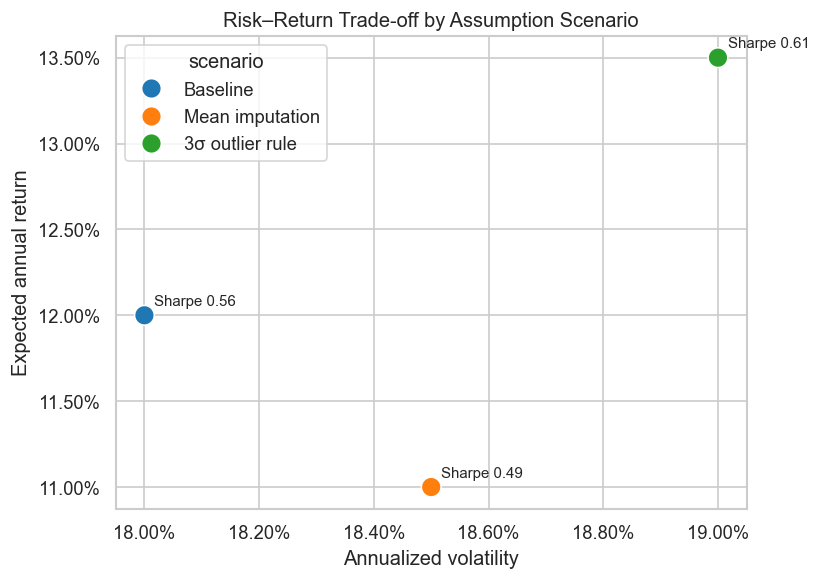

In [5]:
summary = df.drop_duplicates('scenario').copy()
palette = {'Baseline': '#1f77b4', 'Mean imputation': '#ff7f0e', '3σ outlier rule': '#2ca02c'}
plt.figure(figsize=(7,5))
sns.scatterplot(data=summary, x='volatility', y='expected_return', hue='scenario', palette=palette, s=140)
for _, row in summary.iterrows():
    plt.annotate(f"Sharpe {row['sharpe']:.2f}", (row['volatility'], row['expected_return']),
                 xytext=(6, 6), textcoords='offset points', fontsize=9)
plt.title('Risk–Return Trade-off by Assumption Scenario')
plt.xlabel('Annualized volatility')
plt.ylabel('Expected annual return')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
savefig('risk_return.png')
plt.show()

## Chart 2: Return by Scenario (Bar Chart)

Saved return_by_scenario.png


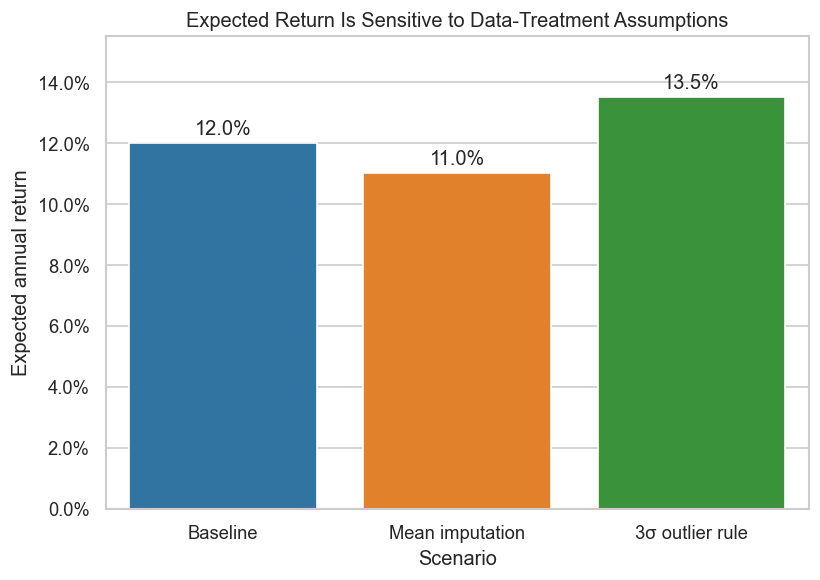

In [6]:
plt.figure(figsize=(7,5))
ax = sns.barplot(data=summary, x='scenario', y='expected_return', hue='scenario', palette=palette, legend=False)
for patch, value in zip(ax.patches, summary['expected_return']):
    ax.annotate(f'{value:.1%}', (patch.get_x() + patch.get_width()/2, patch.get_height()),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')
plt.title('Expected Return Is Sensitive to Data-Treatment Assumptions')
plt.xlabel('Scenario')
plt.ylabel('Expected annual return')
plt.ylim(0, 0.155)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
savefig('return_by_scenario.png')
plt.show()

## Chart 3: Growth of $1 Over Time (Line Chart)

Saved growth_of_one_over_time.png


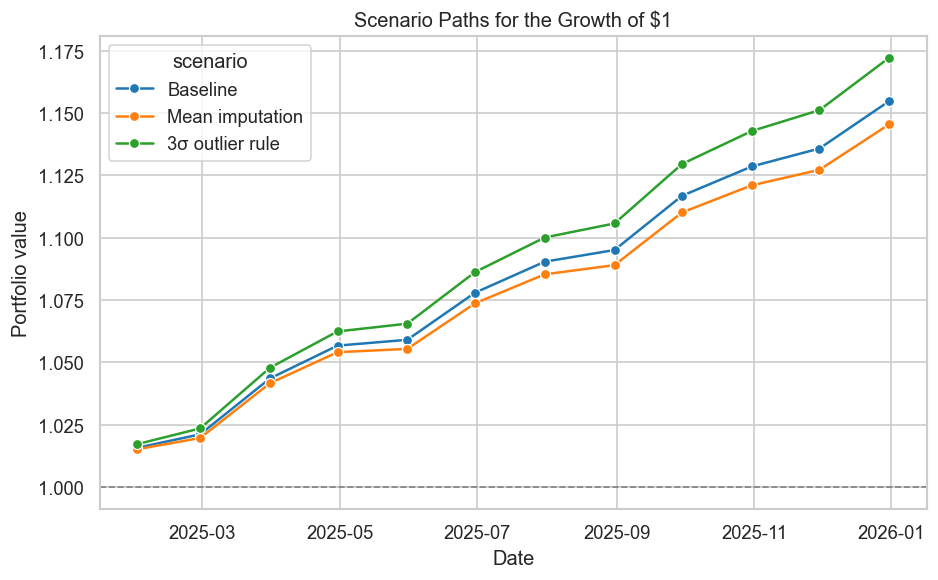

In [7]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='Date', y='growth_of_one', hue='scenario', palette=palette, marker='o')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.title('Scenario Paths for the Growth of $1')
plt.xlabel('Date')
plt.ylabel('Portfolio value')
savefig('growth_of_one_over_time.png')
plt.show()

## Sensitivity Analysis / Assumptions Table

In [8]:
baseline_return = summary.loc[summary['scenario'] == 'Baseline', 'expected_return'].iloc[0]
sensitivity = summary[['scenario', 'assumption', 'expected_return', 'volatility', 'sharpe']].copy()
sensitivity['return_delta_vs_baseline'] = sensitivity['expected_return'] - baseline_return
sensitivity['return_delta_bps'] = sensitivity['return_delta_vs_baseline'] * 10_000
sensitivity.to_csv('reports/sensitivity_summary.csv', index=False)
sensitivity

,scenario,assumption,expected_return,volatility,sharpe,return_delta_vs_baseline,return_delta_bps
0,Baseline,Median imputation,0.120,0.180,0.555556,0.000,0.0
12,Mean imputation,Mean imputation,0.110,0.185,0.486486,-0.010,-100.0
24,3σ outlier rule,Keep observations within 3σ,0.135,0.190,0.605263,0.015,150.0


## Interpretations / Takeaways
- **Risk–return scatter:** The 3σ outlier case has the highest modeled return and Sharpe ratio, but it also has the highest volatility. This is an assumption comparison, not evidence that changing the cleaning rule creates performance.
- **Return bar chart:** Data-treatment choices move expected return from 11.0% to 13.5%. Relative to baseline, mean imputation lowers the estimate by 100 basis points and the 3σ rule raises it by 150 basis points.
- **Growth chart:** Small differences compound over the year, so assumption selection becomes economically visible over time. The common path is synthetic and should be treated as scenario illustration rather than a forecast.

## Assumptions & Risks
- Expected returns and volatility are scenario inputs, not guaranteed outcomes; the 2% risk-free rate used in Sharpe calculations is assumed constant.
- The same monthly pattern is applied across scenarios to isolate assumption effects. It is not an investable backtest and excludes fees, taxes, liquidity constraints, and tail events.
- The 3σ rule can remove legitimate extreme observations and make risk look more manageable than it is. Mean imputation can be distorted by skewed data.

## What This Means for You
- Use the 12.0% baseline for planning and show 11.0%–13.5% as the assumption-driven return range.
- Do not approve a strategy solely because the 3σ treatment reports the highest return; require an out-of-sample check that keeps tail observations visible.
- Revisit the decision if realized volatility exceeds 19%, missingness becomes material, or the ranking changes after fees and stress testing.

## Deliverables
The stakeholder report is saved as `reports/final_report.md`; its three self-contained figures are in `reports/images/`, and `reports/README.md` documents the audience and format choice.